In [387]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from pylr2 import regress2
from scipy.stats import kendalltau

warnings.filterwarnings('ignore', message="Could not infer format")

Configuration:

Defining configuration parameters and file paths for the rainfall analysis project. This includes the file paths for the CORMP, Davis, and OWLR datasets, as well as the start and end timestamps for the analysis period.


In [388]:
FILES = {
    "TR525": "Data/precip_CORMP_03172026.csv",
    "Aerocone": "Data/precip_Davis_04282026.csv",
    "OWLR":  "Data/OWLR_CMS_05072026.csv"
}

START = pd.to_datetime("2025-12-19 09:00")
END   = pd.to_datetime("2026-04-28 08:00")

Analysis wide variables:

Creating reusable functions to clean, align, and process rainfall data across sensors.

In [389]:
def keep_period(df):
    return df[(df["datetime"].between(START, END))].reset_index(drop=True)

def finalize(df, col_name, resample=True):
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df = df[["datetime", col_name]].dropna()
    
    if resample:
        df = df.set_index("datetime").resample("h", closed="right", label="right").sum().reset_index()
#!!!
# when summing for pandas bins  are left-closed, right-open: [11:00, 12:00) and labeled by the left edge sp this code changes it to the other way.

    return keep_period(df)

Sensor-specific changes:

Cleaning and combining rainfall data from different sensors so they all match the same format.

In [390]:
def load_cormp(fp):
    df = pd.read_csv(fp, skiprows=7, usecols=[0, 1])
    df.columns = ["datetime", "rain_mm_tr525"]
    df["rain_mm_tr525"] *= 25.4
    return finalize(df, "rain_mm_tr525")


def load_davis(fp):
    df = pd.read_csv(fp, skiprows=6, names=["datetime", "rain_mm_aerocone","waterLevel_cm_CTD"])
    return finalize(df, "rain_mm_aerocone")


def load_owlr(fp):
    # New OWLR export already has columns split; rainfall is the 7th column (index 6).
    df = pd.read_csv(fp, header=None, skiprows=1)
    df = df.rename(columns={1: "datetime", 6: "rain_mm_owlr"})
    df = df[["datetime", "rain_mm_owlr"]]
    return finalize(df, "rain_mm_owlr", resample=False)

def prepare(df, name):
    df["datetime"] = df["datetime"].dt.floor("h")
    return df.rename(columns={"rain_mm_owlr": name})


Loads raw rainfall data from each sensor, standardizes it, and merges everything into one combined dataset for comparison in future analyses. 

In [391]:
print("Loading and processing rainfall data...")

TR525 = prepare(load_cormp(FILES["TR525"]), "rain_mm_tr525")
Aerocone = prepare(load_davis(FILES["Aerocone"]), "rain_mm_aerocone")
OWLR  = prepare(load_owlr(FILES["OWLR"]),  "rain_mm_owlr")

rainfall_all = (
    TR525.merge(Aerocone, on="datetime", how="outer")
          .merge(OWLR, on="datetime", how="outer")
)

print(f"  TR-525l: {len(TR525)} hourly records")
print(f"  Aerocone: {len(Aerocone)} hourly records")
print(f"  OWLR: {len(OWLR)} hourly records")
print(f"  Zero rainfall points (OWLR): {np.sum(OWLR['rain_mm_owlr'] == 0)}") #checking zero amounts
print(f"  Combined comparison table: {rainfall_all.shape}")



Loading and processing rainfall data...
  TR-525l: 2118 hourly records
  Aerocone: 3120 hourly records
  OWLR: 4006 hourly records
  Zero rainfall points (OWLR): 3893
  Combined comparison table: (4018, 4)


In [392]:
TR525.iloc[360:380]

,datetime,rain_mm_tr525
360,2026-01-03 09:00:00,0.000
361,2026-01-03 10:00:00,0.000
362,2026-01-03 11:00:00,0.000
363,2026-01-03 12:00:00,1.016
364,2026-01-03 13:00:00,2.032
365,2026-01-03 14:00:00,1.016
366,2026-01-03 15:00:00,0.000
367,2026-01-03 16:00:00,0.762
368,2026-01-03 17:00:00,0.508
369,2026-01-03 18:00:00,0.254


In [393]:
Aerocone.iloc[360:380]

,datetime,rain_mm_aerocone
360,2026-01-03 09:00:00,0.0
361,2026-01-03 10:00:00,0.0
362,2026-01-03 11:00:00,0.0
363,2026-01-03 12:00:00,1.0
364,2026-01-03 13:00:00,2.1
365,2026-01-03 14:00:00,1.1
366,2026-01-03 15:00:00,0.0
367,2026-01-03 16:00:00,1.1
368,2026-01-03 17:00:00,0.8
369,2026-01-03 18:00:00,0.6


In [394]:
OWLR.iloc[360:380]

,datetime,rain_mm_owlr
360,2026-01-03 08:00:00,0.00
361,2026-01-03 09:00:00,0.00
362,2026-01-03 10:00:00,0.00
363,2026-01-03 11:00:00,0.00
364,2026-01-03 12:00:00,0.56
365,2026-01-03 13:00:00,1.68
366,2026-01-03 14:00:00,0.28
367,2026-01-03 15:00:00,0.00
368,2026-01-03 16:00:00,0.84
369,2026-01-03 17:00:00,0.56


In [395]:
rainfall_all.iloc[2150:2200]

,datetime,rain_mm_tr525,rain_mm_aerocone,rain_mm_owlr
2150,2026-03-09 00:00:00,0.000,0.9,0.00
2151,2026-03-09 01:00:00,0.000,0.0,0.00
2152,2026-03-09 02:00:00,1.270,0.0,0.00
2153,2026-03-09 03:00:00,0.762,1.6,0.28
2154,2026-03-09 04:00:00,0.254,1.0,0.00
2155,2026-03-09 05:00:00,0.000,0.0,0.00
2156,2026-03-09 06:00:00,0.000,0.0,0.00
2157,2026-03-09 07:00:00,0.000,0.0,0.00
2158,2026-03-09 08:00:00,0.000,0.0,0.00
2159,2026-03-09 09:00:00,0.000,0.0,0.00


Global names and colors

In [396]:
SENSORS = {
    "TR525": {
        "col": "rain_mm_tr525",
        "label": "TR525l",
        "color": "blue",
        "marker": "s",
        "is_ref": True
    },
    "Aerocone": {
        "col": "rain_mm_aerocone",
        "label": "Aerocone",
        "color": "black",
        "marker": "o",
        "is_ref": False
    },
    "OWLR": {
        "col": "rain_mm_owlr",
        "label": "OWLR",
        "color": "lightgreen",
        "marker": "^",
        "is_ref": False
    }
}

Finished data sets: 
Extracts a specific time dataset from all sensors, standardizes column names, and ends up optionally applying OWLR calibration which I will use in event specific analyses. 

In [397]:
def filter_window(df, start, end):
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df[(df['datetime'] >= start) & (df['datetime'] <= end)]

def build_event_frame(start, end, calibrate_owlr=False, m=None, b=None):
    df = filter_window(rainfall_all, start, end).copy()

    df = df.rename(columns={
        "tr525_mm":    "rain_mm_tr525",
        "aerocone_mm": "rain_mm_aerocone",
        "owlr_mm":     "rain_mm_owlr"
    })

    if calibrate_owlr:
        if m is None or b is None:
            raise ValueError("Provide calibration coefficients m and b.")
        df["rain_mm_owlr_cal"] = (m * df["rain_mm_owlr"] + b).clip(lower=0)

    return df



Global r-squared: Compares two sensors by matching their data points and calculating how strongly they agree

In [398]:
def paired_metrics(df, x, y):
    pair = df[[x, y]].dropna()
    if len(pair) < 2:
        return pair, np.nan, np.nan
    r = pair[x].corr(pair[y])
    return pair, r, r**2

# Step 1:Type 1 Linear Regression of Aerocone vs. OWLR & TR-525I


In [399]:

XCOL = 'rain_mm_aerocone'

def stats_pair(x, y):
    pair = pd.concat([x, y], axis=1).dropna()

    if len(pair) < 2:
        return pair, np.nan, np.nan, np.nan, np.nan, np.nan

    x_clean = pair.iloc[:, 0]
    y_clean = pair.iloc[:, 1]

    r = x_clean.corr(y_clean)
    r2 = r ** 2 if pd.notna(r) else np.nan
    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    # MAPE
    mask = y_clean != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_clean[mask] - x_clean[mask]) / y_clean[mask])) * 100
    else:
        mape = np.nan

    return pair, r, r2, slope, intercept, mape

# Compare Aerocone (x) against TR525 and OWLR (y)
step1_targets = ['TR525', 'OWLR']
results = {}

for sensor_name in step1_targets:
    cfg = SENSORS[sensor_name]
    col = cfg['col']
    results[sensor_name] = stats_pair(rainfall_all[XCOL], rainfall_all[col])

    pair, r, r2, slope, intercept, mape = results[sensor_name]

    print()
    print('Aerocone vs', sensor_name)
    print('  Paired points:', len(pair))
    print('  R²:', round(r2, 4) if pd.notna(r2) else np.nan)
    print('  Slope:', round(slope, 4) if pd.notna(slope) else np.nan)
    print('  Intercept:', round(intercept, 4) if pd.notna(intercept) else np.nan)
    print('  MAPE (%):', round(mape, 2) if pd.notna(mape) else np.nan)



Aerocone vs TR525
  Paired points: 2533
  R²: 0.4788
  Slope: 0.5895
  Intercept: 0.0339
  MAPE (%): 57.52

Aerocone vs OWLR
  Paired points: 4006
  R²: 0.1723
  Slope: 0.6222
  Intercept: 0.033
  MAPE (%): 185.92


Plotting the Type 1 Linear Regression

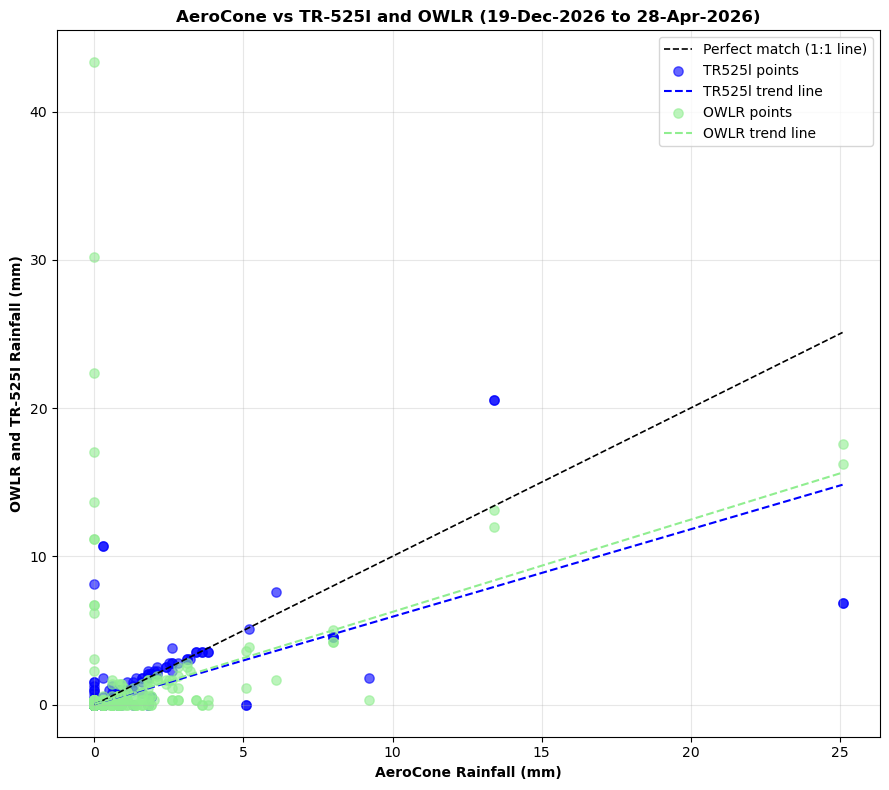

In [400]:
plt.figure(figsize=(9, 8))

# Get Aerocone data (x-axis reference)
aerocone = rainfall_all[XCOL].dropna()
x_min = aerocone.min()
x_max = aerocone.max()

# Draw the perfect fit line
plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Perfect match (1:1 line)'
)

# Compare TR525 and OWLR against Aerocone
for sensor_name in ['TR525', 'OWLR']:
    cfg = SENSORS[sensor_name]
    column = cfg['col']
    color = cfg['color']
    label = cfg['label']

    clean_data = rainfall_all[[XCOL, column]].dropna()
    x_values = clean_data[XCOL]
    y_values = clean_data[column]

    plt.scatter(
        x_values,
        y_values,
        s=45,
        alpha=0.6,
        color=color,
        label=f'{label} points'
    )

    pair, r, r2, slope, intercept, mape = results[sensor_name]
    if pd.notna(slope) and pd.notna(intercept):
        x_line = np.linspace(x_min, x_max, 100)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            '--',
            color=color,
            label=f'{label} trend line'
        )
plt.xlabel('AeroCone Rainfall (mm)', fontweight='bold')
plt.ylabel('OWLR and TR-525I Rainfall (mm)', fontweight='bold')
plt.title('AeroCone vs TR-525I and OWLR (19-Dec-2026 to 28-Apr-2026)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


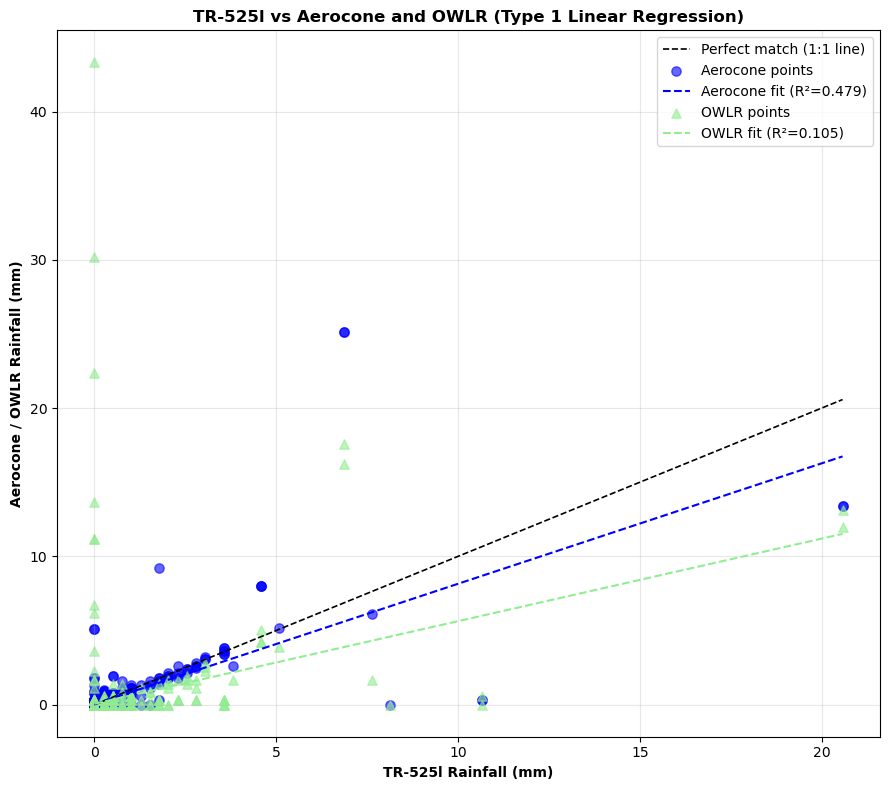


TR-525l vs Aerocone
Paired points: 2533
Slope: 0.812271
Intercept: 0.027380
R²: 0.4788
Equation: Aerocone = 0.812271 * TR-525l + 0.027380

TR-525l vs OWLR
Paired points: 2523
Slope: 0.556945
Intercept: 0.058458
R²: 0.1048
Equation: OWLR = 0.556945 * TR-525l + 0.058458


In [401]:
# TR-525l on x-axis; Aerocone and OWLR on y-axis (Type 1 linear regression)
plt.figure(figsize=(9, 8))

x_col = 'rain_mm_tr525'
x_all = rainfall_all[x_col].dropna()
fit_results = []

if len(x_all) < 2:
    print('Not enough TR-525l data to build regression plot.')
else:
    x_min = x_all.min()
    x_max = x_all.max()

    # 1:1 reference line
    plt.plot(
        [x_min, x_max],
        [x_min, x_max],
        color='black',
        linestyle='--',
        linewidth=1.2,
        label='Perfect match (1:1 line)'
    )

    targets = [
        ('Aerocone', 'rain_mm_aerocone', 'blue', 'o'),
        ('OWLR', 'rain_mm_owlr', 'lightgreen', '^')
    ]

    for label, y_col, color, marker in targets:
        pair = rainfall_all[[x_col, y_col]].dropna()

        if len(pair) < 2:
            print(f'Not enough paired points for TR-525l vs {label}.')
            continue

        x_vals = pair[x_col]
        y_vals = pair[y_col]

        plt.scatter(
            x_vals,
            y_vals,
            s=45,
            alpha=0.6,
            color=color,
            marker=marker,
            label=f'{label} points'
        )

        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        r2 = x_vals.corr(y_vals) ** 2
        fit_results.append((label, len(pair), slope, intercept, r2))

        x_line = np.linspace(x_min, x_max, 200)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            '--',
            color=color,
            label=f'{label} fit (R²={r2:.3f})'
        )

    plt.xlabel('TR-525l Rainfall (mm)', fontweight='bold')
    plt.ylabel('Aerocone / OWLR Rainfall (mm)', fontweight='bold')
    plt.title('TR-525l vs Aerocone and OWLR (Type 1 Linear Regression)', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print fit statistics and equations
    for label, n_points, slope, intercept, r2 in fit_results:
        sign = '-' if intercept < 0 else '+'
        print(f'\nTR-525l vs {label}')
        print(f'Paired points: {n_points}')
        print(f'Slope: {slope:.6f}')
        print(f'Intercept: {intercept:.6f}')
        print(f'R²: {r2:.4f}')
        print(f'Equation: {label} = {slope:.6f} * TR-525l {sign} {abs(intercept):.6f}')

# AeroCone vs. OWLR Linear Regression Plot Type 1

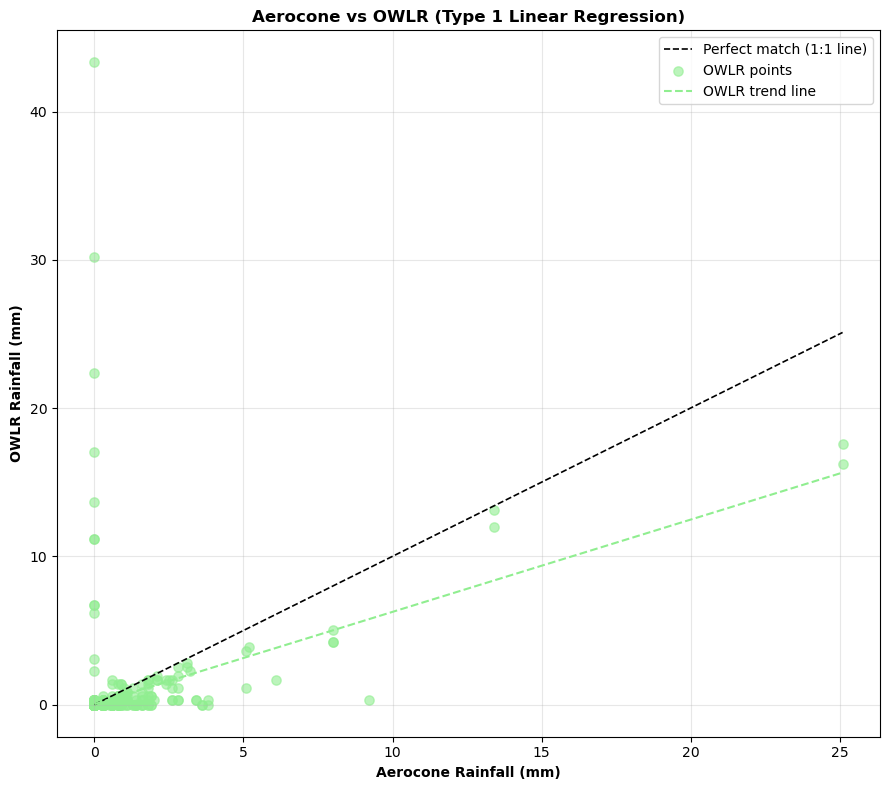

Paired points: 4006
R²: 0.1723
Slope: 0.6222
Intercept: 0.0330


In [402]:
plt.figure(figsize=(9, 8))

# Aerocone on x-axis, OWLR on y-axis
x_col = SENSORS['Aerocone']['col']
y_col = SENSORS['OWLR']['col']

clean_data = rainfall_all[[x_col, y_col]].dropna()
x_values = clean_data[x_col]
y_values = clean_data[y_col]

if len(clean_data) < 2:
    print('Not enough paired points for Aerocone vs OWLR regression.')
else:
    x_min = x_values.min()
    x_max = x_values.max()

    # Perfect match line (1:1)
    plt.plot(
        [x_min, x_max],
        [x_min, x_max],
        color='black',
        linestyle='--',
        linewidth=1.2,
        label='Perfect match (1:1 line)'
    )

    plt.scatter(
        x_values,
        y_values,
        s=45,
        alpha=0.6,
        color=SENSORS['OWLR']['color'],
        label='OWLR points'
    )

    slope, intercept = np.polyfit(x_values, y_values, 1)
    r = x_values.corr(y_values)
    r2 = r**2 if pd.notna(r) else np.nan

    x_line = np.linspace(x_min, x_max, 100)
    y_line = slope * x_line + intercept
    plt.plot(
        x_line,
        y_line,
        '--',
        color=SENSORS['OWLR']['color'],
        label='OWLR trend line'
    )

    plt.xlabel('Aerocone Rainfall (mm)', fontweight='bold')
    plt.ylabel('OWLR Rainfall (mm)', fontweight='bold')
    plt.title('Aerocone vs OWLR (Type 1 Linear Regression)', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Paired points: {len(clean_data)}')
    print(f'R²: {r2:.4f}')
    print(f'Slope: {slope:.4f}')
    print(f'Intercept: {intercept:.4f}')

# Step 2: Calibration of OWLR raw values

Use the AeroCone gauge as the reference measurement, or the closest approximation to “true” rainfall available in the dataset.
Run a linear regression between Aerocone rainfall and raw OWLR rainfall to determine how the OWLR measurements differ from the reference. The regression takes the form:

yOWLR =m (xAerocone) +b

Interpret the regression coefficients:
The slope (m) describes whether OWLR values are systematically scaled too high or too low relative to the Aerocone.
The intercept (b) describes whether OWLR values are consistently offset above or below the reference measurements.
Because the goal is to correct the raw OWLR values, invert the regression equation so that calibrated OWLR values are calculated directly from the raw OWLR measurements:

OWLRcal = (yOWLR - b) / m

Apply this inverted equation to all raw OWLR measurements. This calibration step adjusts the OWLR data by correcting both:
scaling differences (multiplying/dividing by the slope), and
offset differences (adding/subtracting the intercept).
The resulting calibrated OWLR dataset should more closely match the Aerocone reference measurements and therefore better approximate the “true” rainfall values.

In [403]:
# Paired Aerocone–OWLR data
pair_aero_owlr = rainfall_all[['rain_mm_aerocone', 'rain_mm_owlr']].dropna()

if len(pair_aero_owlr) < 2:
    raise ValueError("Not enough paired points for calibration.")

# Linear fit: OWLR = m * Aerocone + b
m, b = np.polyfit(
    pair_aero_owlr['rain_mm_aerocone'],
    pair_aero_owlr['rain_mm_owlr'],
    1
)

# Calibrate OWLR by inverting regression
pair_aero_owlr['rain_mm_owlr_cal_from_aero'] = (
    (pair_aero_owlr['rain_mm_owlr'] - b) / m
).clip(lower=0)

# Save coefficients
owlr_calibration_from_aero = {'m': m, 'b': b}

# Performance metrics
x = pair_aero_owlr['rain_mm_aerocone']
y_raw = pair_aero_owlr['rain_mm_owlr']
y_cal = pair_aero_owlr['rain_mm_owlr_cal_from_aero']

print('Aerocone -> OWLR calibration')
print(f'OWLR = {m:.6f} * Aerocone + {b:.6f}')
print(f'Calibrated OWLR = (OWLR_raw - {b:.6f}) / {m:.6f}')
print(f'Paired points: {len(pair_aero_owlr)}')

print(
    f'R² raw: {x.corr(y_raw)**2:.4f} | '
    f'RMSE raw: {np.sqrt(np.mean((y_raw - x)**2)):.4f} mm'
)

print(
    f'R² calibrated: {x.corr(y_cal)**2:.4f} | '
    f'RMSE calibrated: {np.sqrt(np.mean((y_cal - x)**2)):.4f} mm'
)

# Apply calibration to full dataset
rainfall_all['rain_mm_owlr_cal_from_aero'] = (
    (rainfall_all['rain_mm_owlr'] - b) / m
).clip(lower=0)

Aerocone -> OWLR calibration
OWLR = 0.622169 * Aerocone + 0.033002
Calibrated OWLR = (OWLR_raw - 0.033002) / 0.622169
Paired points: 4006
R² raw: 0.1723 | RMSE raw: 1.0754 mm
R² calibrated: 0.1711 | RMSE calibrated: 1.6644 mm


# Plot calibrated OWLR values

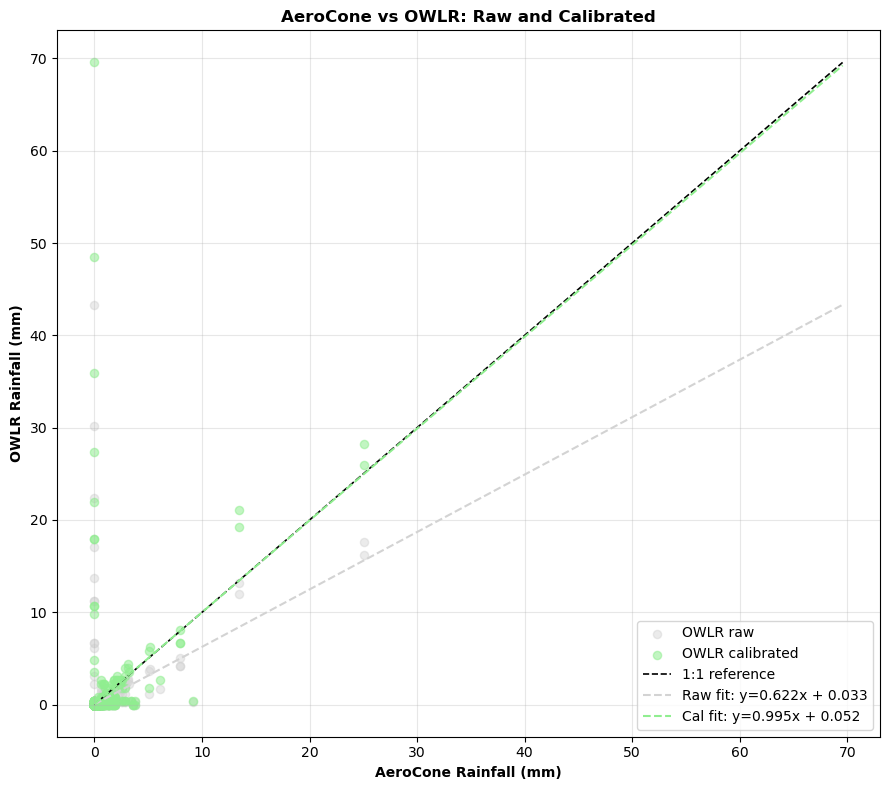

In [404]:
# Plot: Aerocone vs OWLR (raw + calibrated)
x = pair_aero_owlr['rain_mm_aerocone']
y_raw = pair_aero_owlr['rain_mm_owlr']
y_cal = pair_aero_owlr['rain_mm_owlr_cal_from_aero']

plt.figure(figsize=(9, 8))

# Scatter plots
plt.scatter(x, y_raw, s=35, alpha=0.45, color='lightgrey', label='OWLR raw')
plt.scatter(x, y_cal, s=35, alpha=0.55, color='lightgreen', label='OWLR calibrated')

# Axis limits + 1:1 line
xy_min = min(x.min(), y_raw.min(), y_cal.min())
xy_max = max(x.max(), y_raw.max(), y_cal.max())

plt.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    'k--',
    lw=1.2,
    label='1:1 reference'
 )

# Trend lines
for y, color, name in [
    (y_raw, 'lightgrey', 'Raw'),
    (y_cal, 'lightgreen', 'Cal')
]:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(xy_min, xy_max, 200)

    plt.plot(
        x_line,
        slope * x_line + intercept,
        '--',
        color=color,
        label=f'{name} fit: y={slope:.3f}x + {intercept:.3f}'
    )

plt.xlabel('AeroCone Rainfall (mm)', fontweight='bold')
plt.ylabel('OWLR Rainfall (mm)', fontweight='bold')
plt.title('AeroCone vs OWLR: Raw and Calibrated', fontweight='bold')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: Type 2 Regression + Residuals Plots
TR525 vs. Aerocone and OWLR
Assumes that all sensors have error

This step makes sure that for each timestamp there is corresponding data from Tr525 vs. OWLR and TR525 vs. Aerocone so the regression works.

In [405]:
paired_owlr = rainfall_all[['datetime', 'rain_mm_aerocone', 'rain_mm_owlr']].dropna()
paired_tr525 = rainfall_all[['datetime', 'rain_mm_aerocone', 'rain_mm_tr525']].dropna()

# Validate there is enough data
if len(paired_owlr) < 2 or len(paired_tr525) < 2:
    raise ValueError('Not enough overlapping hourly points for Type II regression.')

# Extract variables for regression (Aerocone is x-axis reference)
x = paired_owlr['rain_mm_aerocone'].to_numpy()
y_owlr = paired_owlr['rain_mm_owlr'].to_numpy()
x_tr525 = paired_tr525['rain_mm_aerocone'].to_numpy()
y_tr525 = paired_tr525['rain_mm_tr525'].to_numpy()

In [406]:

fit_owlr = regress2(x, y_owlr, _method_type_2='reduced major axis')
slope_owlr = fit_owlr.get('slope', np.nan)
intercept_owlr = fit_owlr.get('intercept', np.nan)
r_owlr = fit_owlr.get('r', np.corrcoef(x, y_owlr)[0, 1])
r2_owlr = r_owlr**2 if np.isfinite(r_owlr) else np.nan

fit_tr525 = regress2(x_tr525, y_tr525, _method_type_2='reduced major axis')
slope_tr525 = fit_tr525.get('slope', np.nan)
intercept_tr525 = fit_tr525.get('intercept', np.nan)
r_tr525 = fit_tr525.get('r', np.corrcoef(x_tr525, y_tr525)[0, 1])
r2_tr525 = r_tr525**2 if np.isfinite(r_tr525) else np.nan

# OWLR residuals using Aerocone as x
y_hat = slope_owlr * x + intercept_owlr
residuals = y_owlr - y_hat
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
resid_mean = np.mean(residuals)
resid_std = np.std(residuals, ddof=1)

# MAPE for OWLR model
nonzero_mask = y_owlr != 0
mape = np.mean(
    np.abs((y_owlr[nonzero_mask] - y_hat[nonzero_mask]) / y_owlr[nonzero_mask])
) * 100

# Format signs for cleaner equation text
owlr_sign = '-' if intercept_owlr < 0 else '+'
tr525_sign = '-' if intercept_tr525 < 0 else '+'

# Print regression results
print(f'Overlapping hourly points: OWLR={len(paired_owlr)}, TR525={len(paired_tr525)}')
print(f'\nType II RMA regression equations (x = Aerocone):')
print(f'  OWLR = {slope_owlr:.4f} × Aerocone {owlr_sign} {abs(intercept_owlr):.4f}')
print(f'  TR-525l = {slope_tr525:.4f} × Aerocone {tr525_sign} {abs(intercept_tr525):.4f}')
print(f'\nRegression fit statistics:')
print(f'  OWLR: r = {r_owlr:.4f}, r² = {r2_owlr:.4f}')
print(f'  TR-525l: r = {r_tr525:.4f}, r² = {r2_tr525:.4f}')
print(f'\nOWLR residual statistics (mm):')
print(f'  Mean: {resid_mean:.4f} | Std Dev: {resid_std:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}')
print(f'  MAPE: {mape:.2f}%')

print('Total points:', len(residuals))
print('Zero rainfall points (Aerocone):', np.sum(x == 0))
print('Zero rainfall points (OWLR):', np.sum(y_owlr == 0))
print('Zero residuals:', np.sum(np.isclose(residuals, 0)))


Overlapping hourly points: OWLR=4006, TR525=2533

Type II RMA regression equations (x = Aerocone):
  OWLR = 1.4988 × Aerocone - 0.0342
  TR-525l = 0.8519 × Aerocone + 0.0062

Regression fit statistics:
  OWLR: r = 0.4151, r² = 0.1723
  TR-525l: r = 0.6920, r² = 0.4788

OWLR residual statistics (mm):
  Mean: -0.0000 | Std Dev: 1.2322 | MAE: 0.1552 | RMSE: 1.2321
  MAPE: 296.96%
Total points: 4006
Zero rainfall points (Aerocone): 3835
Zero rainfall points (OWLR): 3893
Zero residuals: 0


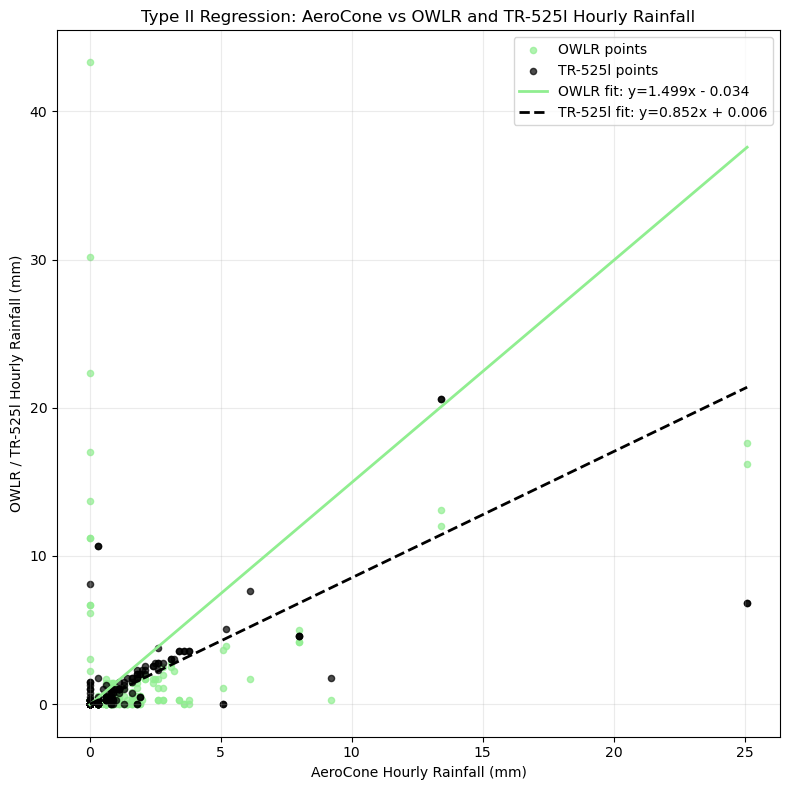

In [407]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y_owlr, s=20, alpha=0.7, color='lightgreen', label='OWLR points')
plt.scatter(x_tr525, y_tr525, s=20, alpha=0.7, color='black', label='TR-525l points')

xmin = min(np.nanmin(x), np.nanmin(x_tr525))
xmax = max(np.nanmax(x), np.nanmax(x_tr525))
xline = np.linspace(xmin, xmax, 200)

# Sign-aware equation labels for clean formatting on the plot
owlr_sign_plot = '-' if intercept_owlr < 0 else '+'
tr525_sign_plot = '-' if intercept_tr525 < 0 else '+'

plt.plot(
    xline,
    slope_owlr * xline + intercept_owlr,
    color='lightgreen',
    lw=2,
    label=f'OWLR fit: y={slope_owlr:.3f}x {owlr_sign_plot} {abs(intercept_owlr):.3f}'
)
plt.plot(
    xline,
    slope_tr525 * xline + intercept_tr525,
    color='black',
    lw=2,
    ls='--',
    label=f'TR-525l fit: y={slope_tr525:.3f}x {tr525_sign_plot} {abs(intercept_tr525):.3f}'
)

plt.xlabel('AeroCone Hourly Rainfall (mm)')
plt.ylabel('OWLR / TR-525l Hourly Rainfall (mm)')
plt.title('Type II Regression: AeroCone vs OWLR and TR-525I Hourly Rainfall')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Plot OWLR residuals vs Aerocone (x-axis)


In [408]:
# Print all OWLR residuals from the Type 2 regression
if 'residuals' not in globals():
    print('Run the Type 2 regression cells first to create residuals.')
else:
    residuals_series = pd.Series(residuals, name='OWLR Residual (mm)')
    print('All OWLR residuals from Type 2 regression:')
    print(residuals_series.to_string(index=True))

    highest_residual = residuals_series.max()
    print(f'\nHighest residual amount: {highest_residual:.4f} mm')


All OWLR residuals from Type 2 regression:
0        0.034246
1        0.034246
2        0.034246
3        0.034246
4        0.034246
5        0.034246
6        0.034246
7        0.034246
8        0.034246
9        0.034246
10       0.034246
11       0.034246
12       0.034246
13       0.034246
14       0.034246
15       0.034246
16       0.034246
17       0.034246
18       0.034246
19       0.034246
20       0.034246
21       0.034246
22       0.034246
23       0.034246
24       0.034246
25       0.034246
26       0.034246
27       0.034246
28       0.034246
29       0.034246
30       0.034246
31       0.034246
32       0.034246
33       0.034246
34       0.034246
35       0.034246
36       0.034246
37       0.034246
38       0.034246
39       0.034246
40       0.034246
41       0.034246
42       0.034246
43       0.034246
44       0.034246
45       0.034246
46       0.034246
47       0.034246
48       0.034246
49       0.034246
50       0.034246
51       0.034246
52       0.034246
53 

-7.981633327310162e-18


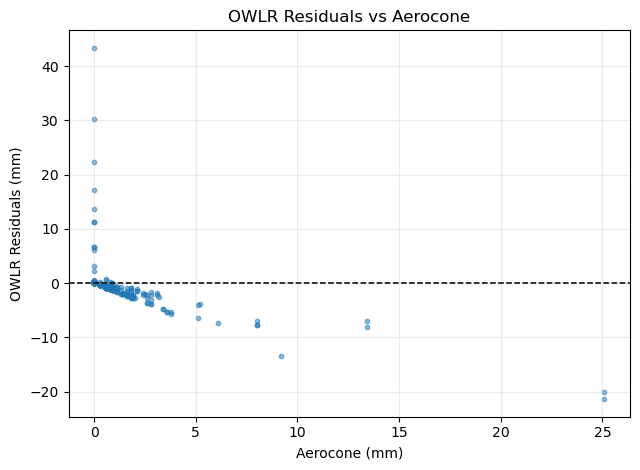

In [409]:
plt.figure(figsize=(6.5, 4.8))
plt.scatter(x, residuals, s=10, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)
plt.xlabel('Aerocone (mm)')
plt.ylabel('OWLR Residuals (mm)')
plt.title('OWLR Residuals vs Aerocone')
print(np.mean(residuals))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Same residuals vs. predicted plot BUT put a mask to only show values during a rain event. 

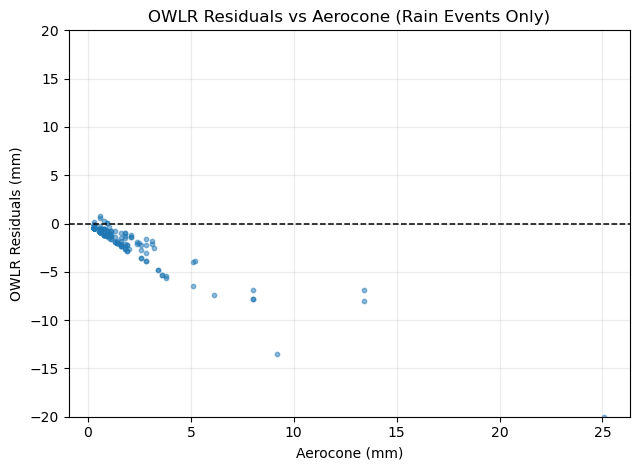

In [410]:

rain_mask = x > 0.1 # .28 is OWLR resolution but made it a little lower.

plt.figure(figsize=(6.5, 4.8))
plt.scatter(x[rain_mask], residuals[rain_mask], s=10, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)

plt.xlabel('Aerocone (mm)')
plt.ylabel('OWLR Residuals (mm)')
plt.title('OWLR Residuals vs Aerocone (Rain Events Only)')
plt.ylim(-20, 20)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Residual distribution (for OWLR comparison)

Uses values only above .1 so it doesn't include all the 0s.

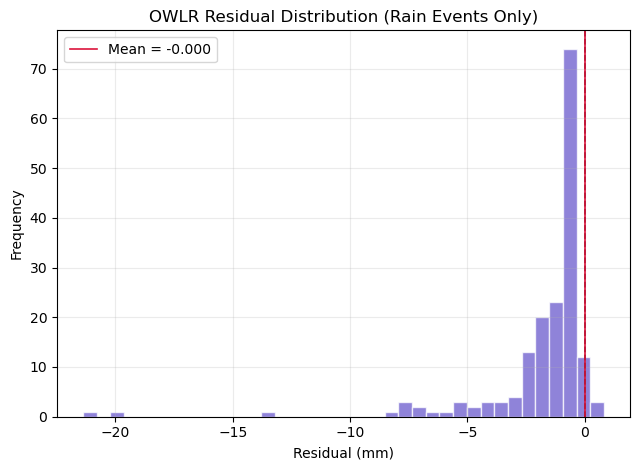

In [411]:

rain_mask = x > 0.1   # .28 is OWLR resolution but made it a little lower. 
residuals_rain = residuals[rain_mask]
y_hat_rain = y_hat[rain_mask]

plt.figure(figsize=(6.5, 4.8))
plt.hist(residuals_rain, bins='auto', color='slateblue', alpha=0.75, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1.1)
plt.axvline(resid_mean, color='crimson', linestyle='-', linewidth=1.2, label=f'Mean = {resid_mean:.3f}')
plt.xlabel('Residual (mm)')
plt.ylabel('Frequency')
plt.title('OWLR Residual Distribution (Rain Events Only)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Step 4: 2D Histogram for TR525 vs. Calibrated OWLR data

Change to owlr raw?

In [412]:
# from matplotlib.colors import LogNorm

# # Calibrated data from above.
# x_hist = owlr_df['rain_mm_tr525'].to_numpy()
# y_hist = owlr_df['owlr_cal'].to_numpy()

# valid = np.isfinite(x_hist) & np.isfinite(y_hist)
# x_hist = x_hist[valid]
# y_hist = y_hist[valid]

# if len(x_hist) < 2:
#     raise ValueError("Not enough valid data for 2D histogram.")

# # Center around mean
# x_anom = x_hist - np.mean(x_hist)
# y_anom = y_hist - np.mean(y_hist)

# # bin size
# bin_size = 0.25
# lim = np.percentile(np.abs(np.concatenate([x_anom, y_anom])), 99)

# edges = np.arange(-lim, lim + bin_size, bin_size)

In [413]:

# fig, ax = plt.subplots(figsize=(8, 6))

# # 2D histogram (density view)
# hist = ax.hist2d(
#     x_anom,
#     y_anom,
#     bins=[edges, edges],
#     cmap='viridis',
#     norm=LogNorm(vmin=1)
# )

# cbar = plt.colorbar(hist[3], ax=ax)
# cbar.set_label("Point density (log scale)")

# ax.axhline(0, color='white', linestyle='--', linewidth=1)
# ax.axvline(0, color='white', linestyle='--', linewidth=1)
# ax.plot([-lim, lim], [-lim, lim], 'w:', linewidth=1.2, label="1:1 line")

# ax.set_xlabel("TR-525l rainfall occurance (mm)")
# ax.set_ylabel("Calibrated OWLR rainfall occurance (mm)")
# ax.set_title("Rainfall Density: TR-525l vs Calibrated OWLR")

# plt.tight_layout()
# plt.show()

# Scatter Plot for TR525, Aerocone, and OWLR Calibrated data for Time Period

TR-525l points plotted: 2533
Aerocone points plotted: 4018
OWLR calibrated points plotted: 4006


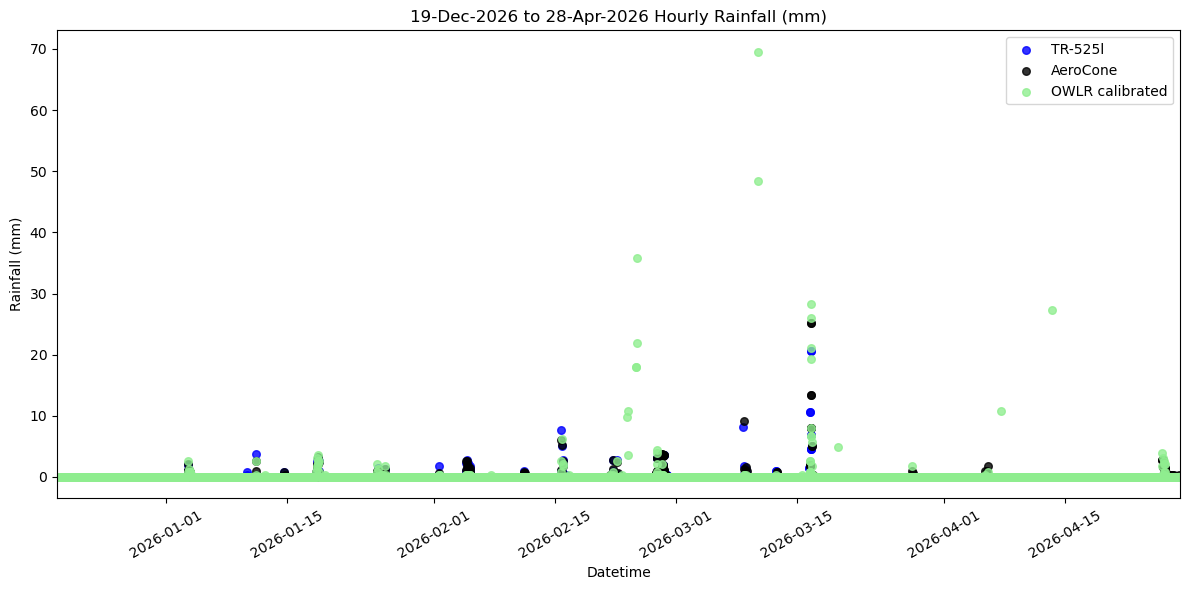

In [414]:
# Ensure the new calibrated OWLR values are available
if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first to create rain_mm_owlr_cal_from_aero.')

    m = coeffs['m']
    b = coeffs['b']
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - b) / m
).clip(lower=0)

# dataframe
plot_df = rainfall_all.copy()
plot_df['rain_mm_owlr_cal'] = plot_df['rain_mm_owlr_cal_from_aero']

# Count points again to make sure
tr525_points = plot_df['rain_mm_tr525'].notna().sum()
aerocone_points = plot_df['rain_mm_aerocone'].notna().sum()
owlr_points = plot_df['rain_mm_owlr_cal'].notna().sum()

print(f'TR-525l points plotted: {tr525_points}')
print(f'Aerocone points plotted: {aerocone_points}')
print(f'OWLR calibrated points plotted: {owlr_points}')

plt.figure(figsize=(12, 6))
if not plot_df['rain_mm_tr525'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_tr525'], label='TR-525l', s=30, alpha=0.8, color='blue')
if not plot_df['rain_mm_aerocone'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_aerocone'], label='AeroCone', s=30, alpha=0.8, color='black')
if not plot_df['rain_mm_owlr_cal'].isna().all():
    plt.scatter(plot_df['datetime'], plot_df['rain_mm_owlr_cal'], label='OWLR calibrated', s=30, alpha=0.8, color='lightgreen')

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('19-Dec-2026 to 28-Apr-2026 Hourly Rainfall (mm)')
plt.legend()
plt.xlim(START, END)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Non-Zero Rainfall Events Linear Regression

Calculations for linear regression once all zero values are excluded for all sensors

In [415]:
# Create calibrated OWLR if missing
if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:

    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run calibration cell first.')

    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

# Compare sensors against Aerocone
x_col = 'rain_mm_aerocone'

plot_pairs = [
    ('TR-525I', 'rain_mm_tr525', 'black'),
    ('OWLR calibrated', 'rain_mm_owlr_cal_from_aero', 'lightgreen')
]

results = []
summary_lines = []
all_values = []

for label, col, color in plot_pairs:

    pair = rainfall_all[[x_col, col]].dropna()
    pair = pair[(pair[x_col] > 0) & (pair[col] > 0)]

    if len(pair) < 2:
        summary_lines.append(f'{label}: not enough data')
        continue

    x = pair[x_col]
    y = pair[col]

    slope, intercept = np.polyfit(x, y, 1)
    r2 = x.corr(y) ** 2

    results.append({
        'label': label,
        'color': color,
        'x': x,
        'y': y,
        'x_line': np.linspace(x.min(), x.max(), 100),
        'y_line': slope * np.linspace(x.min(), x.max(), 100) + intercept,
        'slope': slope,
        'intercept': intercept,
        'r2': r2
    })

    all_values.append(max(x.max(), y.max()))

    summary_lines.append(
        f'{label}: n={len(pair)}, '
        f'R²={r2:.3f}, '
        f'y={slope:.4f}x + {intercept:.4f}'
    )

Plotting the non-zero linear regression

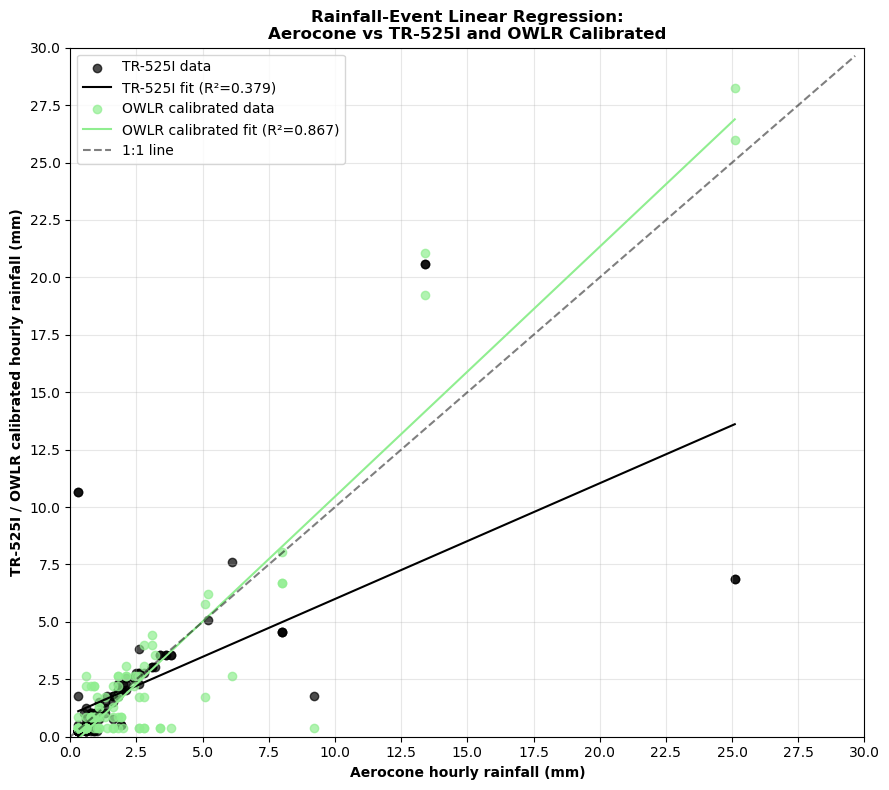

TR-525I: n=105, R²=0.379, y=0.5039x + 0.9598
OWLR calibrated: n=87, R²=0.867, y=1.0878x + -0.4201


In [416]:
plt.figure(figsize=(9, 8))

# Plot data + regression lines
for res in results:

    plt.scatter(
        res['x'],
        res['y'],
        color=res['color'],
        alpha=0.7,
        label=f"{res['label']} data"
    )

    plt.plot(
        res['x_line'],
        res['y_line'],
        color=res['color'],
        label=f"{res['label']} fit (R²={res['r2']:.3f})"
    )

# 1:1 reference line
limit = max(all_values) * 1.05 if all_values else 1

plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label='1:1 line')

# Axes formatting
plt.xlim(0, limit)
plt.ylim(0, limit)

ticks = np.arange(0, limit + 2.5, 2.5)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel('Aerocone hourly rainfall (mm)', fontweight='bold')
plt.ylabel('TR-525I / OWLR calibrated hourly rainfall (mm)', fontweight='bold')

plt.title(
    'Rainfall-Event Linear Regression:\n'
    'Aerocone vs TR-525I and OWLR Calibrated',
    fontweight='bold'
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print('\n'.join(summary_lines))

# Non-Zero/Zero Matrix

Computing counts and percantages for each portion on the matrix. 

In [417]:
sensors_cm = [
    ('TR-525I', 'rain_mm_tr525', 'Oranges'),
    ('OWLR', 'rain_mm_owlr', 'Greens'),
]

results = []

for label, col, cmap in sensors_cm:
    df = rainfall_all[['rain_mm_aerocone', col]].dropna()

    aero_zero = df['rain_mm_aerocone'] == 0
    s_zero = df[col] == 0

    # Row order is [Aerocone nonzero, Aerocone zero] so zero-zero is bottom-left.
    counts = np.array([
        [(~aero_zero & s_zero).sum(), (~aero_zero & ~s_zero).sum()],
        [(aero_zero & s_zero).sum(), (aero_zero & ~s_zero).sum()]
    ])

    row_pct = counts / counts.sum(axis=1, keepdims=True) * 100

    results.append({
        'label': label,
        'cmap': cmap,
        'counts': counts,
        'row_pct': row_pct
    })

Plotting the matrix. 

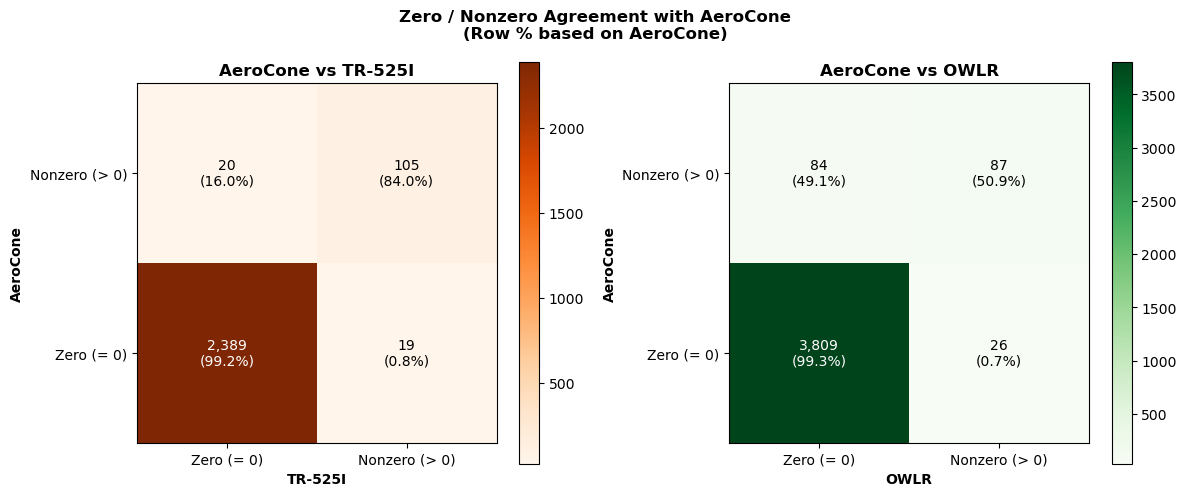

In [418]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res in zip(axes, results):
    counts = res['counts']
    row_pct = res['row_pct']

    im = ax.imshow(counts, cmap=res['cmap'])

    x_labels = ['Zero (= 0)', 'Nonzero (> 0)']
    y_labels = ['Nonzero (> 0)', 'Zero (= 0)']
    ax.set_xticks([0, 1]); ax.set_xticklabels(x_labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(y_labels)

    ax.set_xlabel(res['label'], fontweight='bold')
    ax.set_ylabel('AeroCone', fontweight='bold')
    ax.set_title(f"AeroCone vs {res['label']}", fontweight='bold')

    for i in range(2):
        for j in range(2):
            val = counts[i, j]
            pct = row_pct[i, j]
            color = 'white' if val > counts.max() * 0.6 else 'black'

            ax.text(
                j, i, f"{val:,}\n({pct:.1f}%)",
                ha='center', va='center', color=color
            )

    plt.colorbar(im, ax=ax)

fig.suptitle(
    'Zero / Nonzero Agreement with AeroCone\n(Row % based on AeroCone)',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

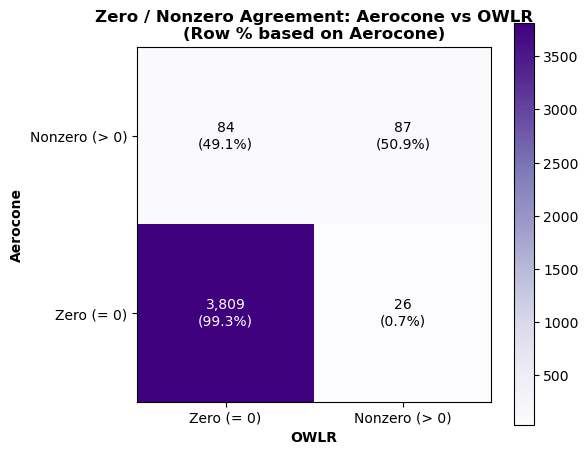

In [419]:
# Zero/Nonzero matrix: Aerocone vs OWLR
df_ao = rainfall_all[['rain_mm_aerocone', 'rain_mm_owlr']].dropna()

aero_zero = df_ao['rain_mm_aerocone'] == 0
owlr_zero  = df_ao['rain_mm_owlr'] == 0

# Row order is [Aerocone nonzero, Aerocone zero] so zero-zero is bottom-left.
counts_ao = np.array([
    [(~aero_zero & owlr_zero).sum(),  (~aero_zero & ~owlr_zero).sum()],
    [(aero_zero & owlr_zero).sum(),   (aero_zero & ~owlr_zero).sum()]
])

row_pct_ao = counts_ao / counts_ao.sum(axis=1, keepdims=True) * 100

fig2, ax2 = plt.subplots(figsize=(6, 5))

im2 = ax2.imshow(counts_ao, cmap='Purples')

x_labels = ['Zero (= 0)', 'Nonzero (> 0)']
y_labels = ['Nonzero (> 0)', 'Zero (= 0)']
ax2.set_xticks([0, 1]); ax2.set_xticklabels(x_labels)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(y_labels)

ax2.set_xlabel('OWLR', fontweight='bold')
ax2.set_ylabel('Aerocone', fontweight='bold')
ax2.set_title('Zero / Nonzero Agreement: Aerocone vs OWLR\n(Row % based on Aerocone)', fontweight='bold')

for i in range(2):
    for j in range(2):
        val = counts_ao[i, j]
        pct = row_pct_ao[i, j]
        color = 'white' if val > counts_ao.max() * 0.6 else 'black'
        ax2.text(j, i, f"{val:,}\n({pct:.1f}%)",
                 ha='center', va='center', color=color)

plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

# Linear Regression for rainfall events for Aerocone vs. OWLR

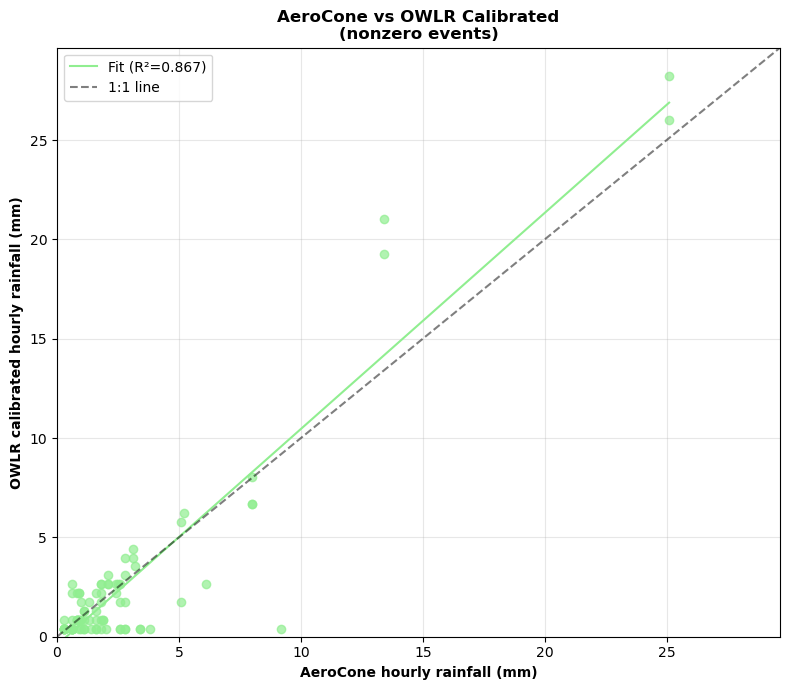

n=87, R²=0.867, y=1.088x + -0.420


In [420]:
# Aerocone vs calibrated OWLR regression

aero_col = 'rain_mm_aerocone'
owlr_col = 'rain_mm_owlr_cal_from_aero'

# Create calibrated OWLR if missing
if owlr_col not in rainfall_all.columns:

    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run calibration cell first.')

    rainfall_all[owlr_col] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

# Prepare paired event data
df = rainfall_all[[aero_col, owlr_col]].dropna()
df = df[(df[aero_col] > 0) & (df[owlr_col] > 0)]

if len(df) < 2:
    print('Not enough data for regression.')

else:
    x = df[aero_col]
    y = df[owlr_col]

    # Regression statistics
    m, b = np.polyfit(x, y, 1)
    r2 = x.corr(y) ** 2

    # Plot settings
    x_line = np.linspace(x.min(), x.max(), 100)
    lim = max(x.max(), y.max()) * 1.05

    # Plot
    plt.figure(figsize=(8, 7))

    plt.scatter(x, y, color='lightgreen', alpha=0.7)

    plt.plot(
        x_line,
        m * x_line + b,
        color='lightgreen',
        label=f'Fit (R²={r2:.3f})'
    )

    plt.plot(
        [0, lim],
        [0, lim],
        'k--',
        alpha=0.5,
        label='1:1 line'
    )

    plt.xlim(0, lim)
    plt.ylim(0, lim)

    plt.xlabel('AeroCone hourly rainfall (mm)', fontweight='bold')
    plt.ylabel('OWLR calibrated hourly rainfall (mm)', fontweight='bold')

    plt.title(
        'AeroCone vs OWLR Calibrated\n(nonzero events)',
        fontweight='bold'
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f'n={len(df)}, '
        f'R²={r2:.3f}, '
        f'y={m:.3f}x + {b:.3f}'
    )

Window rows (all paired timestamps): 29


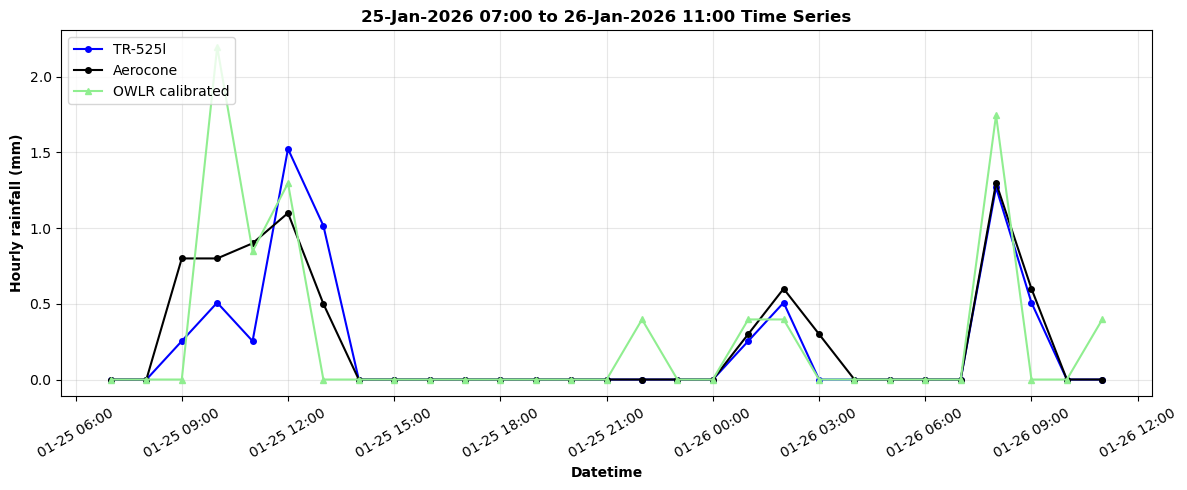


All paired rows in time-series window:
           datetime  rain_mm_tr525  rain_mm_aerocone  rain_mm_owlr_cal_from_aero
2026-01-25 07:00:00          0.000               0.0                    0.000000
2026-01-25 08:00:00          0.000               0.0                    0.000000
2026-01-25 09:00:00          0.254               0.8                    0.000000
2026-01-25 10:00:00          0.508               0.8                    2.197149
2026-01-25 11:00:00          0.254               0.9                    0.847033
2026-01-25 12:00:00          1.524               1.1                    1.297072
2026-01-25 13:00:00          1.016               0.5                    0.000000
2026-01-25 14:00:00          0.000               0.0                    0.000000
2026-01-25 15:00:00          0.000               0.0                    0.000000
2026-01-25 16:00:00          0.000               0.0                    0.000000
2026-01-25 17:00:00          0.000               0.0                 

In [421]:
# Time-series only: TR525, Aerocone, and OWLR calibrated
# Window: Jan 25, 2026 07:00 to Jan 26, 2026 11:00

import matplotlib.dates as mdates

if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first.')
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

start_window = pd.Timestamp('2026-01-25 07:00:00')
end_window = pd.Timestamp('2026-01-26 11:00:00')

ref_col = 'rain_mm_tr525'
aero_col = 'rain_mm_aerocone'
owlr_col = 'rain_mm_owlr_cal_from_aero'
cols = [ref_col, aero_col, owlr_col]

# Filter window, collapse any duplicate timestamps, and keep rows with all 3 sensors.
paired_all = (
    rainfall_all.loc[rainfall_all['datetime'].between(start_window, end_window), ['datetime', *cols]]
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .dropna(subset=cols)
    .sort_values('datetime')
)

print(f'Window rows (all paired timestamps): {len(paired_all)}')

if paired_all.empty:
    print('No paired data found in this window after requiring all sensors.')
else:
    plt.figure(figsize=(12, 5))

    series_cfg = [
        ('TR-525l', ref_col, 'blue', 'o'),
        ('Aerocone', aero_col, SENSORS['Aerocone']['color'], 'o'),
        ('OWLR calibrated', owlr_col, 'lightgreen', '^'),
    ]

    for label, col, color, marker in series_cfg:
        plt.plot(
            paired_all['datetime'],
            paired_all[col],
            f'-{marker}',
            color=color,
            ms=4,
            label=label
        )

    plt.xlabel('Datetime', fontweight='bold')
    plt.ylabel('Hourly rainfall (mm)', fontweight='bold')
    plt.title('25-Jan-2026 07:00 to 26-Jan-2026 11:00 Time Series', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper left')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print('\nAll paired rows in time-series window:')
    print(paired_all[['datetime', ref_col, aero_col, owlr_col]].to_string(index=False))

Window rows (all paired timestamps): 37


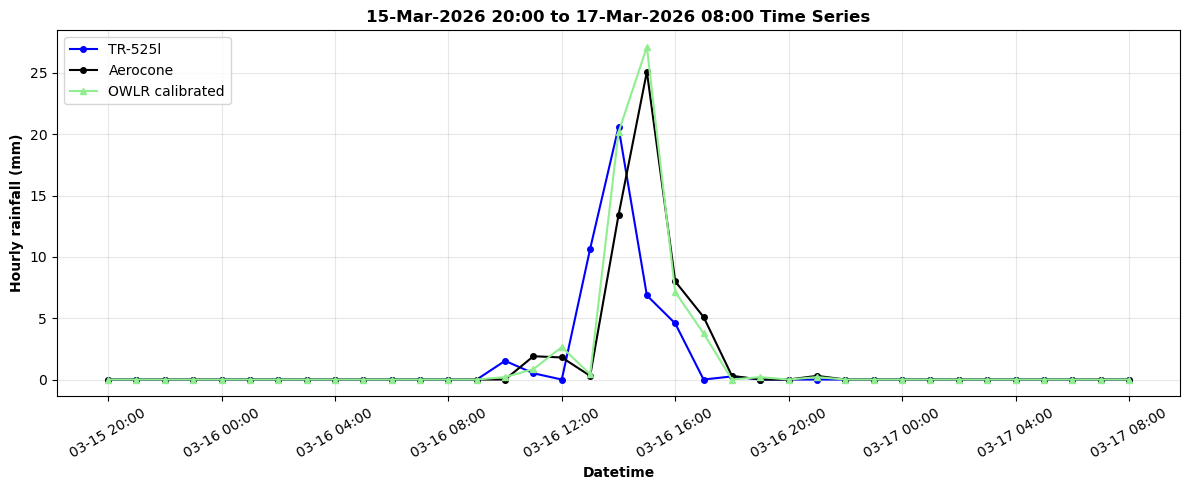

In [422]:
# Time-series only: TR525, Aerocone, and OWLR calibrated
# Window: Mar 15, 2026 20:00 to Mar 17, 2026 08:00

import matplotlib.dates as mdates

if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first.')
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

start_window = pd.Timestamp('2026-03-15 20:00:00')
end_window = pd.Timestamp('2026-03-17 08:00:00')

ref_col = 'rain_mm_tr525'
aero_col = 'rain_mm_aerocone'
owlr_col = 'rain_mm_owlr_cal_from_aero'
cols = [ref_col, aero_col, owlr_col]

paired_window = (
    rainfall_all.loc[rainfall_all['datetime'].between(start_window, end_window), ['datetime', *cols]]
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .dropna(subset=cols)
    .sort_values('datetime')
)

print(f'Window rows (all paired timestamps): {len(paired_window)}')

if paired_window.empty:
    print('No paired data found in this window after requiring all sensors.')
else:
    plt.figure(figsize=(12, 5))

    series_cfg = [
        ('TR-525l', ref_col, 'blue', 'o'),
        ('Aerocone', aero_col, SENSORS['Aerocone']['color'], 'o'),
        ('OWLR calibrated', owlr_col, 'lightgreen', '^'),
    ]

    for label, col, color, marker in series_cfg:
        plt.plot(
            paired_window['datetime'],
            paired_window[col],
            f'-{marker}',
            color=color,
            ms=4,
            label=label
        )

    plt.xlabel('Datetime', fontweight='bold')
    plt.ylabel('Hourly rainfall (mm)', fontweight='bold')
    plt.title('15-Mar-2026 20:00 to 17-Mar-2026 08:00 Time Series', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper left')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

Window rows (all paired timestamps): 25


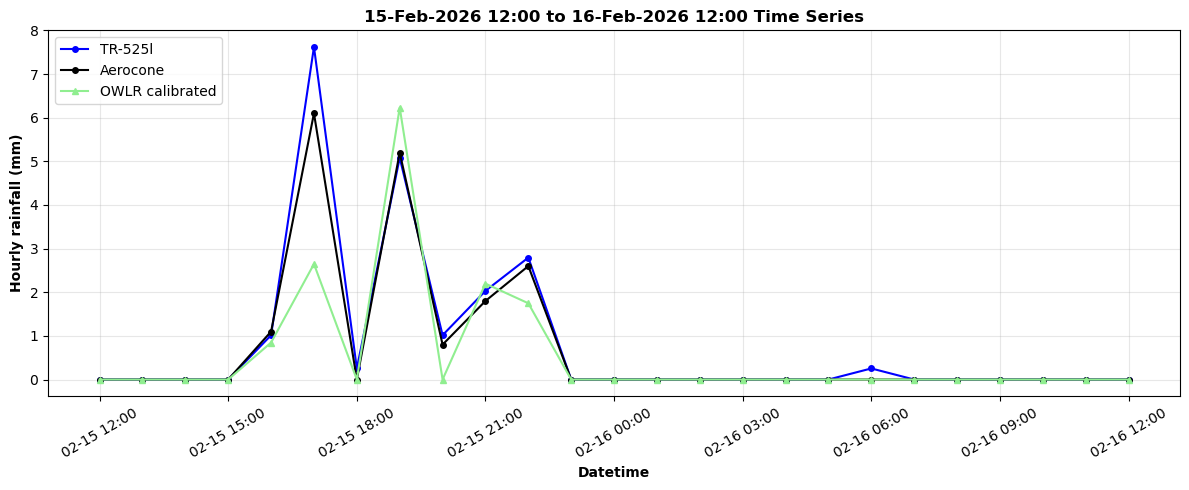

In [423]:
# Time-series only: TR525, Aerocone, and OWLR calibrated
# Window: Feb 15, 2026 12:00 to Feb 16, 2026 12:00

import matplotlib.dates as mdates

if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first.')
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

start_window = pd.Timestamp('2026-02-15 12:00:00')
end_window = pd.Timestamp('2026-02-16 12:00:00')

ref_col = 'rain_mm_tr525'
aero_col = 'rain_mm_aerocone'
owlr_col = 'rain_mm_owlr_cal_from_aero'
cols = [ref_col, aero_col, owlr_col]

paired_window = (
    rainfall_all.loc[rainfall_all['datetime'].between(start_window, end_window), ['datetime', *cols]]
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .dropna(subset=cols)
    .sort_values('datetime')
)

print(f'Window rows (all paired timestamps): {len(paired_window)}')

if paired_window.empty:
    print('No paired data found in this window after requiring all sensors.')
else:
    plt.figure(figsize=(12, 5))

    series_cfg = [
        ('TR-525l', ref_col, 'blue', 'o'),
        ('Aerocone', aero_col, SENSORS['Aerocone']['color'], 'o'),
        ('OWLR calibrated', owlr_col, 'lightgreen', '^'),
    ]

    for label, col, color, marker in series_cfg:
        plt.plot(
            paired_window['datetime'],
            paired_window[col],
            f'-{marker}',
            color=color,
            ms=4,
            label=label
        )

    plt.xlabel('Datetime', fontweight='bold')
    plt.ylabel('Hourly rainfall (mm)', fontweight='bold')
    plt.title('15-Feb-2026 12:00 to 16-Feb-2026 12:00 Time Series', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper left')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [424]:
# Diagnostic: locate the maximum OWLR residual and whether it appears in rain-only plot
if 'paired_owlr' not in globals() or 'residuals' not in globals() or 'y_hat' not in globals():
    print('Run the Type 2 regression cells first (paired_owlr, residuals, y_hat are required).')
else:
    aero_vals = paired_owlr['rain_mm_aerocone'].to_numpy()
    owlr_vals = paired_owlr['rain_mm_owlr'].to_numpy()

    max_idx = int(np.argmax(residuals))
    max_resid = float(residuals[max_idx])

    in_rain_mask = bool(aero_vals[max_idx] > 0.1)
    visible_with_current_ylim = (-20 <= max_resid <= 20)

    print(f'Max residual position: {max_idx}')
    print(f'Max residual value: {max_resid:.4f} mm')
    print(f'Aerocone at max residual: {float(aero_vals[max_idx]):.4f} mm')
    print(f'OWLR observed at max residual: {float(owlr_vals[max_idx]):.4f} mm')
    print(f'OWLR predicted at max residual: {float(y_hat[max_idx]):.4f} mm')
    print(f'Included in rain-only mask (Aerocone > 0.1): {in_rain_mask}')
    print(f'Visible with y-limits [-20, 20]: {visible_with_current_ylim}')

    if 'datetime' in paired_owlr.columns:
        print(f'Datetime at max residual: {paired_owlr.iloc[max_idx]["datetime"]}')


Max residual position: 2180
Max residual value: 43.3442 mm
Aerocone at max residual: 0.0000 mm
OWLR observed at max residual: 43.3100 mm
OWLR predicted at max residual: -0.0342 mm
Included in rain-only mask (Aerocone > 0.1): False
Visible with y-limits [-20, 20]: False
Datetime at max residual: 2026-03-10 12:00:00


# Passing–Bablok Regression is a nonparametric approac. This is actually very appropriate for your rainfall sensor data because several assumptions required for classical parametric agreement analyses are likely violated.
Your dataset appears to contain:
•	many zero observations, 
•	skewed rainfall distributions, 
•	heteroscedasticity (variance increasing with rainfall intensity), 
•	possible outliers during heavy rainfall events, 
•	non-normal residuals, 
•	intensity-dependent bias. 
These characteristics make nonparametric methods highly valuable.

# TR-525 (x) vs OWLR (y)

In [425]:
# Passing-Bablok regression using the existing rainfall columns directly
pair_pb = rainfall_all[['rain_mm_tr525', 'rain_mm_owlr']].dropna()

x = pair_pb['rain_mm_tr525'].to_numpy()
y = pair_pb['rain_mm_owlr'].to_numpy()

# -----------------------------------
# Passing-Bablok Regression
# -----------------------------------
slopes = []
n = len(x)

for i in range(n - 1):
    for j in range(i + 1, n):
        if x[j] != x[i]:
            slope = (y[j] - y[i]) / (x[j] - x[i])
            # Exclude slope = -1
            if slope != -1:
                slopes.append(slope)

slopes = np.array(slopes)

if len(slopes) == 0:
    raise ValueError('Passing-Bablok slope set is empty; check for constant/duplicate x values.')

# Median slope
pb_slope = np.median(slopes)

# Median intercept
pb_intercept = np.median(y - pb_slope * x)

# Predicted values
y_hat = pb_slope * x + pb_intercept

# Residuals
residuals = y - y_hat

# Performance metrics
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
bias = np.mean(residuals)

# Correlation
tau, pval = kendalltau(x, y)

# -----------------------------------
# Print Results
# -----------------------------------
print('Passing-Bablok Regression Results')
print('----------------------------------')
print(f'Slope:      {pb_slope:.4f}')
print(f'Intercept:  {pb_intercept:.4f}')
print(f'Kendall τ:  {tau:.4f}')
print(f'RMSE:       {rmse:.4f}')
print(f'MAE:        {mae:.4f}')
print(f'Bias:       {bias:.4f}')

Passing-Bablok Regression Results
----------------------------------
Slope:      0.1225
Intercept:  0.0000
Kendall τ:  0.6200
RMSE:       1.3583
MAE:        0.1073
Bias:       0.1003


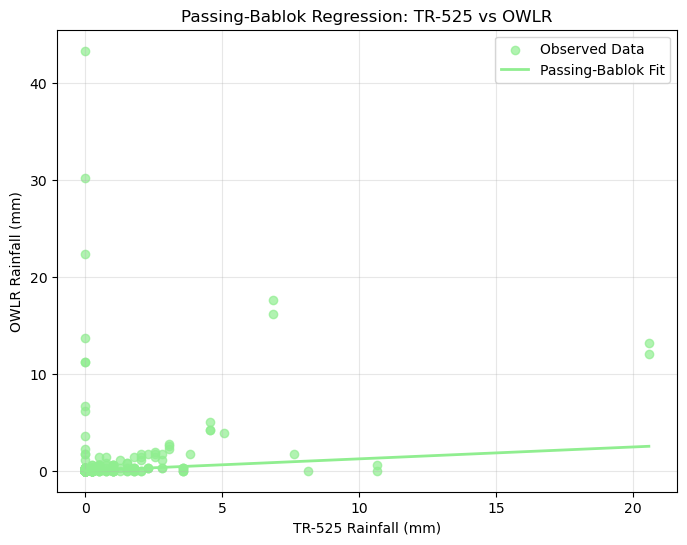

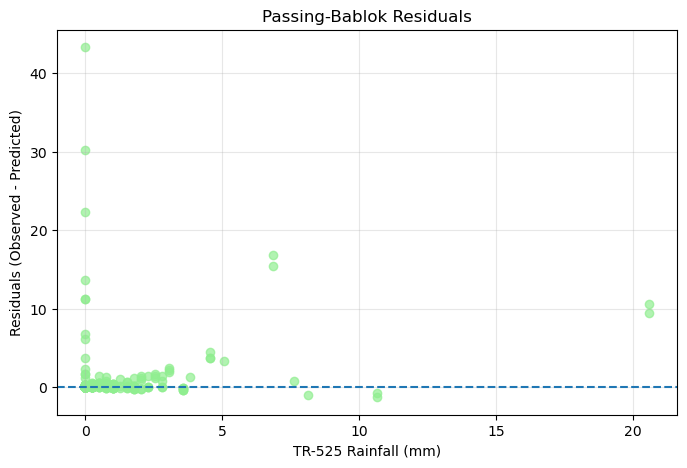

In [426]:
# -----------------------------------
# Scatter Plot + Regression Line
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color='lightgreen', label='Observed Data')

# Sort for clean line plotting
sort_idx = np.argsort(x)
plt.plot(
    x[sort_idx],
    y_hat[sort_idx],
    linewidth=2,
    color='lightgreen',
    label='Passing-Bablok Fit'
 )

plt.xlabel('TR-525 Rainfall (mm)')
plt.ylabel('OWLR Rainfall (mm)')
plt.title('Passing-Bablok Regression: TR-525 vs OWLR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------------
# Residual Plot
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x, residuals, alpha=0.7, color='lightgreen')
plt.axhline(0, linestyle='--')
plt.xlabel('TR-525 Rainfall (mm)')
plt.ylabel('Residuals (Observed - Predicted)')
plt.title('Passing-Bablok Residuals')
plt.grid(True, alpha=0.3)
plt.show()

In [427]:
# Passing-Bablok regression using Aerocone and calibrated OWLR
if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first.')
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

pair_pb = rainfall_all[['rain_mm_aerocone', 'rain_mm_owlr_cal_from_aero']].dropna()

x = pair_pb['rain_mm_aerocone'].to_numpy()
y = pair_pb['rain_mm_owlr_cal_from_aero'].to_numpy()

# -----------------------------------
# Passing-Bablok Regression
# -----------------------------------
slopes = []
n = len(x)

for i in range(n - 1):
    for j in range(i + 1, n):
        if x[j] != x[i]:
            slope = (y[j] - y[i]) / (x[j] - x[i])
            # Exclude slope = -1
            if slope != -1:
                slopes.append(slope)

slopes = np.array(slopes)

if len(slopes) == 0:
    raise ValueError('Passing-Bablok slope set is empty; check for constant/duplicate x values.')

# Median slope
pb_slope = np.median(slopes)

# Median intercept
pb_intercept = np.median(y - pb_slope * x)

# Predicted values
y_hat = pb_slope * x + pb_intercept

# Residuals
residuals = y - y_hat

# Performance metrics
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
bias = np.mean(residuals)

# Correlation
tau, pval = kendalltau(x, y)

# -----------------------------------
# Print Results
# -----------------------------------
print('Passing-Bablok Regression Results (Aerocone vs OWLR calibrated)')
print('------------------------------------------------------------')
print(f'Slope:      {pb_slope:.4f}')
print(f'Intercept:  {pb_intercept:.4f}')
print(f'Kendall τ:  {tau:.4f}')
print(f'RMSE:       {rmse:.4f}')
print(f'MAE:        {mae:.4f}')
print(f'Bias:       {bias:.4f}')

Passing-Bablok Regression Results (Aerocone vs OWLR calibrated)
------------------------------------------------------------
Slope:      0.1045
Intercept:  0.0000
Kendall τ:  0.6142
RMSE:       1.7999
MAE:        0.1238
Bias:       0.1202


# Passing-Bablock for AeroCone vs. OWLR

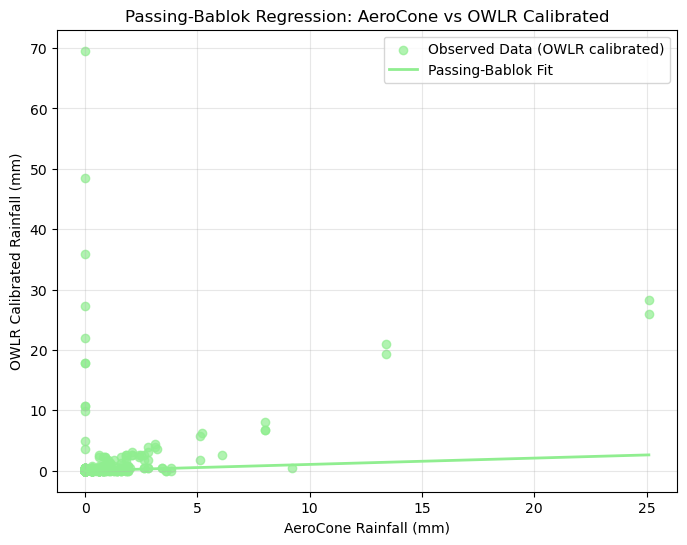

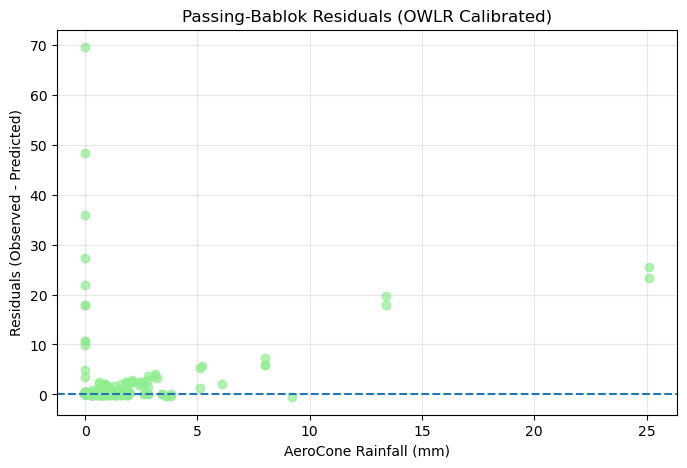

In [428]:
# -----------------------------------
# Scatter Plot + Regression Line
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color='lightgreen', label='Observed Data (OWLR calibrated)')

# Sort for clean line plotting
sort_idx = np.argsort(x)
plt.plot(
    x[sort_idx],
    y_hat[sort_idx],
    linewidth=2,
    color='lightgreen',
    label='Passing-Bablok Fit'
 )

plt.xlabel('AeroCone Rainfall (mm)')
plt.ylabel('OWLR Calibrated Rainfall (mm)')
plt.title('Passing-Bablok Regression: AeroCone vs OWLR Calibrated')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------------
# Residual Plot
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x, residuals, alpha=0.7, color='lightgreen')
plt.axhline(0, linestyle='--')
plt.xlabel('AeroCone Rainfall (mm)')
plt.ylabel('Residuals (Observed - Predicted)')
plt.title('Passing-Bablok Residuals (OWLR Calibrated)')
plt.grid(True, alpha=0.3)
plt.show()

# Band Altman Analysis

In [429]:
# Bland-Altman using TR-525 and OWLR rainfall (mm)
pair_ba = rainfall_all[['rain_mm_tr525', 'rain_mm_owlr']].dropna()

if len(pair_ba) < 2:
    raise ValueError('Not enough paired TR-525 and OWLR points for Bland-Altman analysis.')

sensor_1 = pair_ba['rain_mm_tr525']
sensor_2 = pair_ba['rain_mm_owlr']

# Mean of paired measurements
mean_values = (sensor_1 + sensor_2) / 2

# Difference between paired measurements (TR-525 minus OWLR)
differences = sensor_1 - sensor_2

# Statistics
bias = np.mean(differences)
std_diff = np.std(differences, ddof=1)

# Limits of agreement
upper_loa = bias + 1.96 * std_diff
lower_loa = bias - 1.96 * std_diff

print('Bland-Altman Results (TR-525 vs OWLR)')
print('-------------------------------------')
print(f'Paired points: {len(pair_ba)}')
print(f'Bias: {bias:.3f} mm')
print(f'Std Dev: {std_diff:.3f} mm')
print(f'Upper LoA: {upper_loa:.3f} mm')
print(f'Lower LoA: {lower_loa:.3f} mm')


Bland-Altman Results (TR-525 vs OWLR)
-------------------------------------
Paired points: 2523
Bias: -0.016 mm
Std Dev: 1.357 mm
Upper LoA: 2.643 mm
Lower LoA: -2.675 mm


Bland–Altman analysis demonstrated strong overall agreement between the TR-525 and OWLR rainfall measurements. The mean bias was −0.010 mm, indicating minimal systematic difference between sensors. The 95% limits of agreement ranged from −2.558 mm to 2.538 mm, suggesting that most paired rainfall observations differed by less than approximately ±2.5 mm. While individual rainfall events exhibited some variability between sensors, the near-zero bias indicates that neither instrument consistently over- or under-estimated rainfall relative to the other. These results support the overall comparability of the two sensing approaches for rainfall monitoring applications.

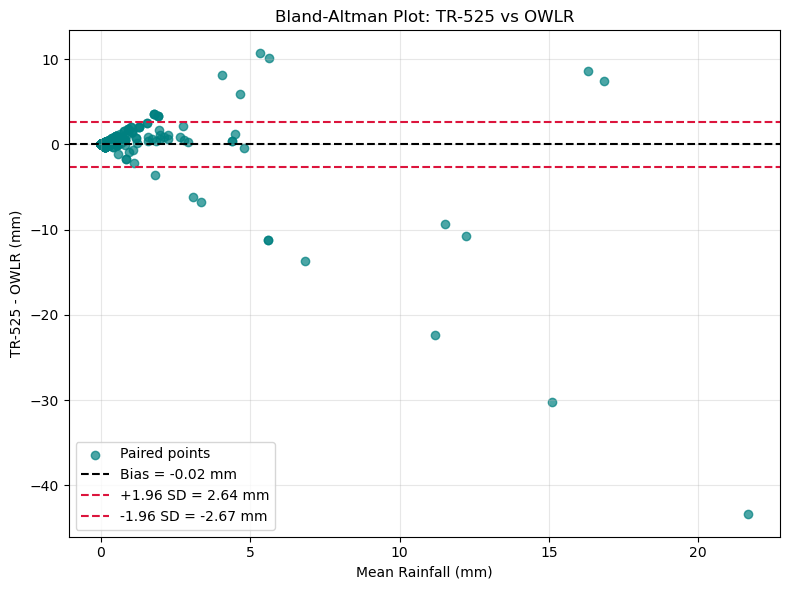

In [430]:

plt.figure(figsize=(8, 6))
plt.scatter(mean_values, differences, alpha=0.7, color='teal', label='Paired points')

# Bias and LoA lines
plt.axhline(bias, linestyle='--', color='black', label=f'Bias = {bias:.2f} mm')
plt.axhline(upper_loa, linestyle='--', color='crimson', label=f'+1.96 SD = {upper_loa:.2f} mm')
plt.axhline(lower_loa, linestyle='--', color='crimson', label=f'-1.96 SD = {lower_loa:.2f} mm')

plt.title('Bland-Altman Plot: TR-525 vs OWLR')
plt.xlabel('Mean Rainfall (mm)')
plt.ylabel('TR-525 - OWLR (mm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [431]:
# Bland-Altman using Aerocone and OWLR calibrated rainfall (mm)
if 'rain_mm_owlr_cal_from_aero' not in rainfall_all.columns:
    coeffs = globals().get('owlr_calibration_from_aero')
    if coeffs is None:
        raise ValueError('Run the Aerocone-based calibration cell first.')
    rainfall_all['rain_mm_owlr_cal_from_aero'] = (
        (rainfall_all['rain_mm_owlr'] - coeffs['b']) / coeffs['m']
    ).clip(lower=0)

pair_ba = rainfall_all[['rain_mm_aerocone', 'rain_mm_owlr_cal_from_aero']].dropna()

if len(pair_ba) < 2:
    raise ValueError('Not enough paired Aerocone and calibrated OWLR points for Bland-Altman analysis.')

sensor_1 = pair_ba['rain_mm_aerocone']
sensor_2 = pair_ba['rain_mm_owlr_cal_from_aero']

# Mean of paired measurements
mean_values = (sensor_1 + sensor_2) / 2

# Difference between paired measurements (Aerocone minus calibrated OWLR)
differences = sensor_1 - sensor_2

# Statistics
bias = np.mean(differences)
std_diff = np.std(differences, ddof=1)

# Limits of agreement
upper_loa = bias + 1.96 * std_diff
lower_loa = bias - 1.96 * std_diff

print('Bland-Altman Results (Aerocone vs OWLR calibrated)')
print('-------------------------------------')
print(f'Paired points: {len(pair_ba)}')
print(f'Bias: {bias:.3f} mm')
print(f'Std Dev: {std_diff:.3f} mm')
print(f'Upper LoA: {upper_loa:.3f} mm')
print(f'Lower LoA: {lower_loa:.3f} mm')

Bland-Altman Results (Aerocone vs OWLR calibrated)
-------------------------------------
Paired points: 4006
Bias: -0.052 mm
Std Dev: 1.664 mm
Upper LoA: 3.210 mm
Lower LoA: -3.313 mm


Bland–Altman analysis demonstrated strong agreement between AeroCone and OWLR rainfall measurements. The mean bias was −0.004 mm, indicating essentially no systematic difference between sensors. The 95% limits of agreement ranged from −2.112 mm to 2.104 mm, suggesting that most paired observations differed by less than approximately ±2.1 mm. Compared to previous analyses, the reduced standard deviation and narrower limits of agreement indicate improved consistency between the two sensing approaches. Overall, these results support the reliability and comparability of the Aerocone and OWLR systems for rainfall monitoring applications.

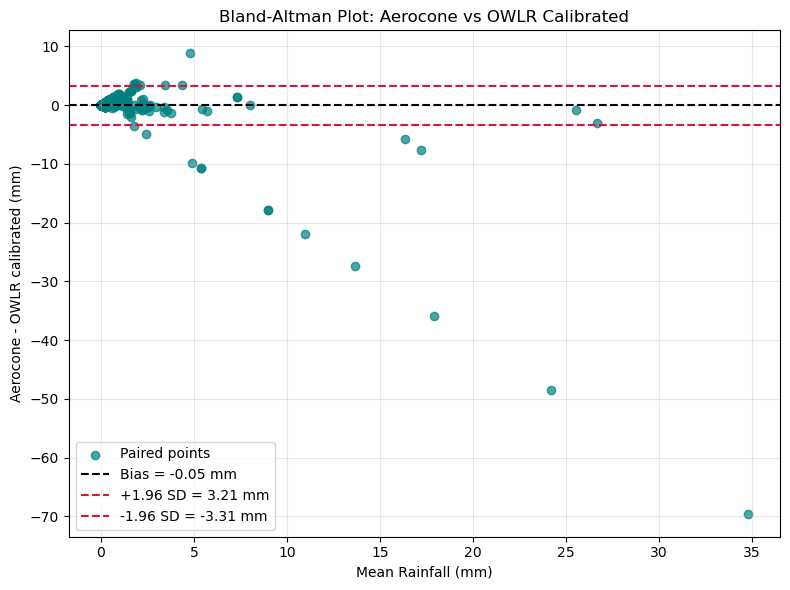

In [432]:

plt.figure(figsize=(8, 6))
plt.scatter(mean_values, differences, alpha=0.7, color='teal', label='Paired points')

# Bias and LoA lines
plt.axhline(bias, linestyle='--', color='black', label=f'Bias = {bias:.2f} mm')
plt.axhline(upper_loa, linestyle='--', color='crimson', label=f'+1.96 SD = {upper_loa:.2f} mm')
plt.axhline(lower_loa, linestyle='--', color='crimson', label=f'-1.96 SD = {lower_loa:.2f} mm')

plt.title('Bland-Altman Plot: Aerocone vs OWLR Calibrated')
plt.xlabel('Mean Rainfall (mm)')
plt.ylabel('Aerocone - OWLR calibrated (mm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()